In [1]:
import numpy as np

print("=== 2.2 编程题 ===")

# 1. 创建 3x4 随机矩阵 X (标准正态分布)
X = np.random.randn(3, 4)
print("矩阵 X (3x4):")
print(X)

# 2. 创建 4x2 全1矩阵 Y
Y = np.ones((4, 2))
print("\n矩阵 Y (4x2):")
print(Y)

# 3. 计算矩阵乘法 Z = X x Y
Z = np.dot(X, Y) # 或 X @ Y
print("\n矩阵 Z (3x2):")
print(Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素 (索引 [0, 1])
#    以及 Z 的第 2 行所有元素 (索引 [1, :])
element = Z[0, 1]
row_two = Z[1, :]
print(f"\nZ[0,1] (第一行第二列交叉): {element}")
print(f"Z 第二行所有元素: {row_two}")

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print(f"Z 的 Frobenius 范数: {fro_norm}")

=== 2.2 编程题 ===
矩阵 X (3x4):
[[-0.02250745 -1.30774096  0.23230827 -0.43059179]
 [-0.30393681 -0.73326113 -1.6782188   0.69572967]
 [ 1.14073279 -0.73732047 -0.3882822  -0.41011701]]

矩阵 Y (4x2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z (3x2):
[[-1.52853194 -1.52853194]
 [-2.01968707 -2.01968707]
 [-0.39498688 -0.39498688]]

Z[0,1] (第一行第二列交叉): -1.528531936605397
Z 第二行所有元素: [-2.01968707 -2.01968707]
Z 的 Frobenius 范数: 3.625344230794686



=== 3.2 编程题 (中心极限定理) ===


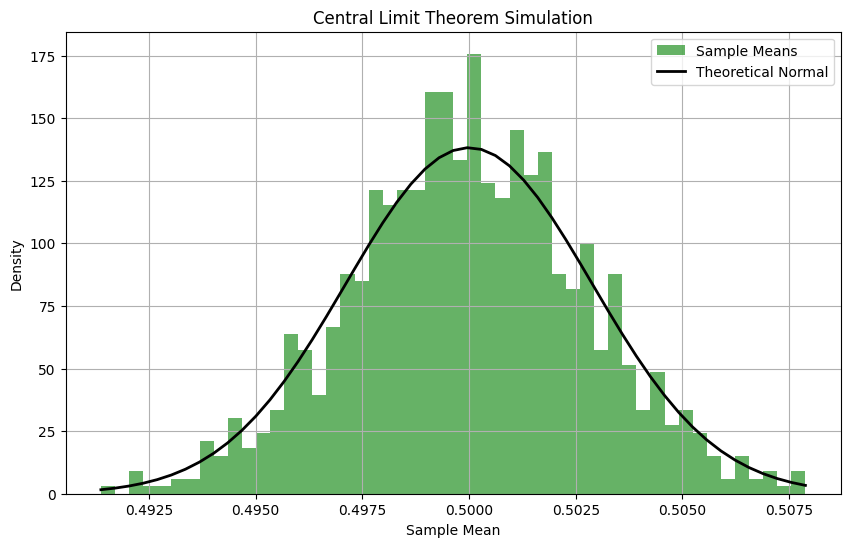

实际均值的方差: 0.000008
理论均值的方差 ((1/12)/10000): 0.000008


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("\n=== 3.2 编程题 (中心极限定理) ===")

n = 10000 # 每次实验的样本数
m = 1000 # 实验重复次数

# 1. 生成数据并计算均值
means = []
for _ in range(m):
    samples = np.random.uniform(0, 1, n) # 均匀分布 U(0, 1)
    mean_val = np.mean(samples)
    means.append(mean_val)

means = np.array(means)

# 2. 绘制直方图和理论曲线
plt.figure(figsize=(10, 6))

# 直方图 (归一化为密度)
count, bins, ignored = plt.hist(means, bins=50, density=True, alpha=0.6, color='g', label='Sample Means')

# 理论正态分布参数
# 均匀分布 U(a,b) 的均值 mu = (a+b)/2 = 0.5
# 均匀分布 U(a,b) 的方差 sigma^2 = (b-a)^2 / 12 = 1/12
# 样本均值的分布方差为 sigma^2 / n
mu_theory = 0.5
sigma_theory = np.sqrt(1/12) / np.sqrt(n)

# 绘制理论曲线
pdf = norm.pdf(bins, mu_theory, sigma_theory)
plt.plot(bins, pdf, 'k', linewidth=2, label='Theoretical Normal')

plt.title('Central Limit Theorem Simulation')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# 3. 计算实际方差
actual_variance = np.var(means)
print(f"实际均值的方差: {actual_variance:.6f}")
print(f"理论均值的方差 ((1/12)/{n}): {1/(12*n):.6f}")

In [5]:
import torch

print("\n=== 4.2 编程题 (反向传播) ===")

# 1. 定义变量 (需要计算梯度)
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 2. 前向计算
a = x * w1
b = a + w2
L = b ** 2

print(f"前向结果 L: {L.item()}")

# 3. 反向传播
L.backward()

# 4. 输出梯度
print(f"自动微分 dL/dw1: {w1.grad.item()}") # 应为 2*b * 1 = 2*(3+0.5)*1.5? 等等，我们来算一下
# 手动验证：
# b = (2*1.5) + 0.5 = 3.5
# L = 3.5^2 = 12.25
# dL/db = 2*3.5 = 7
# db/da = 1, da/dw1 = x = 2
# dL/dw1 = 7 * 1 * 2 = 14
# dL/dw2 = 7 * 1 = 7
print(f"自动微分 dL/dw2: {w2.grad.item()}")

print("\n手动推导验证:")
# 手动计算 (链式法则)
b_val = (x * w1 + w2).item()
manual_dw1 = 2 * b_val * x.item() # dL/db * db/da * da/dw1
manual_dw2 = 2 * b_val # dL/db * db/dw2
print(f"手动计算 dL/dw1: {manual_dw1}")
print(f"手动计算 dL/dw2: {manual_dw2}")


=== 4.2 编程题 (反向传播) ===
前向结果 L: 12.25
自动微分 dL/dw1: 14.0
自动微分 dL/dw2: 7.0

手动推导验证:
手动计算 dL/dw1: 14.0
手动计算 dL/dw2: 7.0



=== 6.2 编程题 (逻辑回归) ===
训练集形状: X=(320, 2), y=(320, 1)
训练完成，最终损失: 0.1300
测试集准确率: 93.75%


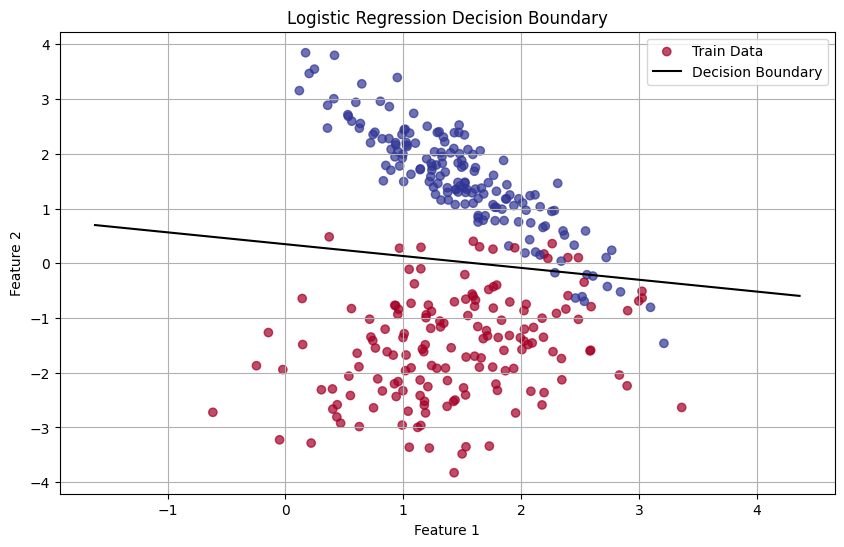

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

print("\n=== 6.2 编程题 (逻辑回归) ===")

# 1. 生成数据 (两类，每类200个，2维特征)
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, 
                           n_informative=2, n_clusters_per_class=1, 
                           class_sep=1.5, random_state=42)
# 将 y 从 (0,1) 转为列向量
X_train, X_test, y_train, y_test = train_test_split(X, y.reshape(-1, 1), test_size=0.2, random_state=42)

print(f"训练集形状: X={X_train.shape}, y={y_train.shape}")

# 2. 定义 Sigmoid 和 损失函数
def sigmoid(z):
    # 防止溢出
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    # 二元交叉熵
    m = len(y_true)
    # 加极小值防止 log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -1/m * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# 3. 训练参数
learning_rate = 0.1
n_iterations = 1000
m_train = X_train.shape[0]

# 初始化参数 (增加偏置项 b)
# 将 X 扩展为 [X, 1] 以便将 w 和 b 合并计算
X_train_bias = np.hstack([X_train, np.ones((m_train, 1))])
w = np.random.randn(3, 1) * 0.1 # w1, w2, b

loss_history = []

for i in range(n_iterations):
    # 前向传播
    z = X_train_bias @ w
    y_prob = sigmoid(z)
    
    # 计算损失
    loss = compute_loss(y_train, y_prob)
    loss_history.append(loss)
    
    # 计算梯度 (向量化)
    # dL/dw = 1/m * X.T @ (y_prob - y_true)
    dw = 1/m_train * X_train_bias.T @ (y_prob - y_train)
    
    # 更新参数
    w -= learning_rate * dw

print(f"训练完成，最终损失: {loss_history[-1]:.4f}")

# 4. 测试与绘图
# 测试集预测
X_test_bias = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
z_test = X_test_bias @ w
y_test_prob = sigmoid(z_test)
y_pred = (y_test_prob > 0.5).astype(int)
accuracy = np.mean(y_pred == y_test)
print(f"测试集准确率: {accuracy * 100:.2f}%")

# 绘制决策边界和数据点
plt.figure(figsize=(10, 6))
# 绘制散点图
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap='RdYlBu', alpha=0.7, label='Train Data')

# 绘制决策边界: w0*x0 + w1*x1 + w2 = 0 -> x1 = -(w0*x0 + w2)/w1
w0, w1, b = w.ravel()
x_line = np.linspace(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 100)
y_line = -(w0 * x_line + b) / w1
plt.plot(x_line, y_line, 'k-', label='Decision Boundary')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()